In [15]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
dataset_path = kagglehub.dataset_download('apollo2506/facial-recognition-dataset')

print('Data source import complete.')
print("Dataset downloaded at:", dataset_path)

Using Colab cache for faster access to the 'facial-recognition-dataset' dataset.
Data source import complete.
Dataset downloaded at: /kaggle/input/facial-recognition-dataset


# **Introduction**

One of the important ways humans display emotions is through facial expressions. Facial expression recognition is one of the most powerful, natural and immediate means for human beings to communicate their emotions and intensions. Humans can be in some circumstances restricted from showing their emotions, such as hospitalized patients, or due to deficiencies; hence, better recognition of other human emotions will lead to effective communication. Automatic human emotion recognition has received much attention recently with the introduction of IOT and smart environments at hospitals, smart homes and smart cities. Intelligent personal assistants (IPAs), such as Siri, Alexia, Cortana and others, use natural language processing to communicate with humans, but when augmented with emotions, it increases the level of effective communication and human-level intelligence.

![](https://ars.els-cdn.com/content/image/1-s2.0-S235291482030201X-gr1.jpg)

A convolutional neural network was used in our system to obtain improved facial emotion detection as it is applied to other computer fields such as face recognition and object detection. In addition, predictions are based on information given at a particular time.

Fig shows the network structure that is used for emotion detection using facial landmarks. This network takes an input image and attempts to predict the output emotion.

![](https://ars.els-cdn.com/content/image/1-s2.0-S235291482030201X-gr6.jpg)

Load data

**Import libraries**

In [38]:
import numpy as np
from tqdm import tqdm
import cv2
import os
import tensorflow as tf
import tensorflow_hub as hub
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

import itertools
import plotly.graph_objs as go
from plotly.offline import init_notebook_mode, iplot
from plotly import tools

from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras import layers
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.callbacks import EarlyStopping

init_notebook_mode(connected=True)
RANDOM_SEED = 123


# **Load Data and Plot Samples**

In [20]:
TRAIN_DIR = "/kaggle/input/facial-recognition-dataset/Training/Training/"
TEST_DIR  = "/kaggle/input/facial-recognition-dataset/Testing/Testing/"


In [21]:
def load_data(dir_path, IMG_SIZE):

    X = []
    y = []
    i = 0
    labels = dict()
    for path in tqdm(sorted(os.listdir(dir_path))):
        if not path.startswith('.'):
            labels[i] = path
            for file in os.listdir(dir_path + path):
                if not file.startswith('.'):
                    img = cv2.imread(dir_path + path + '/' + file)
                    img = img.astype('float32') / 255
                    resized = cv2.resize(img, IMG_SIZE, interpolation = cv2.INTER_AREA)
                    X.append(resized)
                    y.append(i)
            i += 1
    X = np.array(X)
    y = np.array(y)
    print(f'{len(X)} images loaded from {dir_path} directory.')
    return X, y, labels

In [22]:
IMG_SIZE= (48, 48)

In [23]:
X_train, y_train, train_labels = load_data(TRAIN_DIR, IMG_SIZE)

100%|██████████| 6/6 [01:44<00:00, 17.44s/it]


28273 images loaded from /kaggle/input/facial-recognition-dataset/Training/Training/ directory.


In [24]:
train_labels

{0: 'Angry', 1: 'Fear', 2: 'Happy', 3: 'Neutral', 4: 'Sad', 5: 'Suprise'}

In [25]:
X_test, y_test, test_labels = load_data(TEST_DIR,IMG_SIZE)

100%|██████████| 6/6 [00:25<00:00,  4.29s/it]

7067 images loaded from /kaggle/input/facial-recognition-dataset/Testing/Testing/ directory.


In [26]:
def plot_samples(X, y, labels_dict, n=50):

    for index in range(len(labels_dict)):
        imgs = X[np.argwhere(y == index)][:n]
        j = 10
        i = int(n/j)

        plt.figure(figsize=(10,3))
        c = 1
        for img in imgs:
            plt.subplot(i,j,c)
            plt.imshow(img[0])

            plt.xticks([])
            plt.yticks([])
            c += 1
        plt.suptitle(labels_dict[index])
        plt.show()

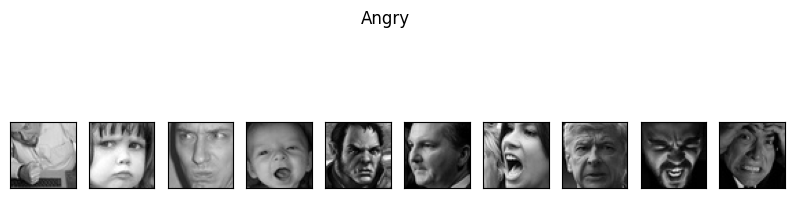

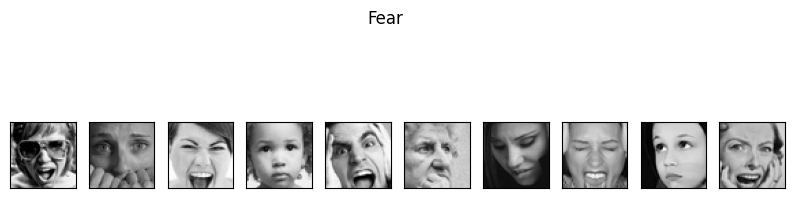

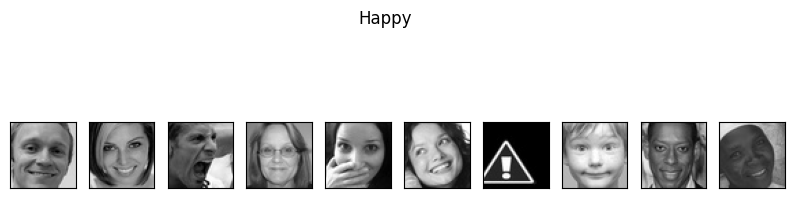

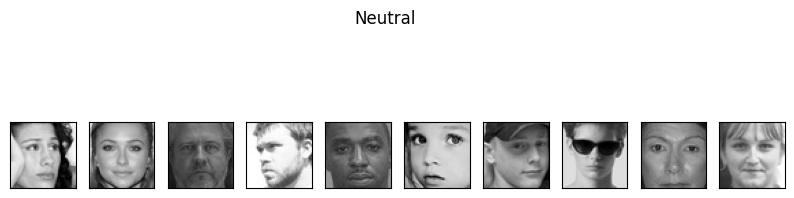

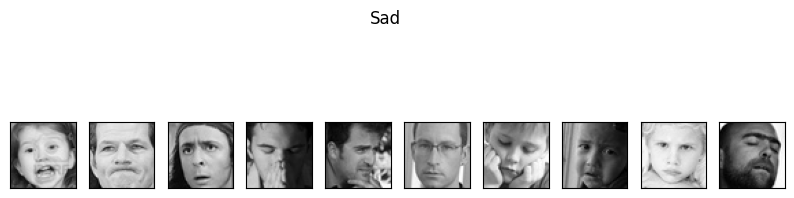

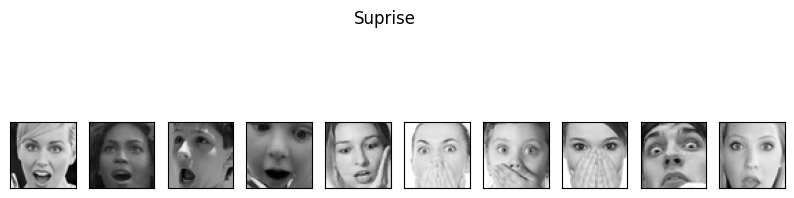

In [27]:
plot_samples(X_train, y_train, train_labels, 10)

**Encoding Classes**

Using the method to_categorical(), a numpy array (or) a vector which has integers that represent different categories, can be converted into a numpy array (or) a matrix which has binary values and has columns equal to the number of categories in the data.

In [29]:
from tensorflow.keras.utils import to_categorical

Y_train = to_categorical(y_train, num_classes=6)
print(Y_train.shape)


(28273, 6)


In [30]:
Y_test = to_categorical(y_test, num_classes=6)
Y_test.shape

(7067, 6)

# **Model Building**

VGG16 is a convolution neural net (CNN ) architecture which was used to win ILSVR(Imagenet) competition in 2014. It is considered to be one of the excellent vision model architecture till date. Most unique thing about VGG16 is that instead of having a large number of hyper-parameter they focused on having convolution layers of 3x3 filter with a stride 1 and always used same padding and maxpool layer of 2x2 filter of stride 2. It follows this arrangement of convolution and max pool layers consistently throughout the whole architecture. In the end it has 2 FC(fully connected layers) followed by a softmax for output. The 16 in VGG16 refers to it has 16 layers that have weights. This network is a pretty large network and it has about 138 million (approx) parameters.

![](https://miro.medium.com/max/940/1*3-TqqkRQ4rWLOMX-gvkYwA.png)

In [31]:
from keras.applications.vgg16 import VGG16

base_model = VGG16(
        weights=None,
        include_top=False,
        input_shape=IMG_SIZE + (3,)
    )

base_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 48, 48, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
NUM_CLASSES = 6
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout

model = Sequential()
model.add(base_model)
model.add(Flatten())
model.add(Dense(1000, activation="relu"))
model.add(Dropout(0.4))
model.add(Dense(NUM_CLASSES, activation="softmax"))


In [36]:
def deep_model(model, X_train, Y_train, epochs, batch_size):

    model.compile(
    loss='binary_crossentropy',
    optimizer=RMSprop(learning_rate=1e-4),
    metrics=['accuracy'])

    history = model.fit(X_train
                       , Y_train
                       , epochs=epochs
                       , batch_size=batch_size
                       , verbose=1)
    return history

In [39]:
epochs = 40
batch_size = 64

history = deep_model(model, X_train, Y_train, epochs, batch_size)


Epoch 1/40
442/442 ━━━━━━━━━━━━━━━━━━━━ 56s 97ms/step - accuracy: 0.2416 - loss: 0.4979
Epoch 2/40
442/442 ━━━━━━━━━━━━━━━━━━━━ 35s 79ms/step - accuracy: 0.2481 - loss: 0.4465
Epoch 3/40
442/442 ━━━━━━━━━━━━━━━━━━━━ 34s 77ms/step - accuracy: 0.2540 - loss: 0.4455
Epoch 4/40
442/442 ━━━━━━━━━━━━━━━━━━━━ 34s 78ms/step - accuracy: 0.2563 - loss: 0.4451
Epoch 5/40
442/442 ━━━━━━━━━━━━━━━━━━━━ 34s 78ms/step - accuracy: 0.2570 - loss: 0.4449
Epoch 6/40
442/442 ━━━━━━━━━━━━━━━━━━━━ 34s 77ms/step - accuracy: 0.2556 - loss: 0.4453
Epoch 7/40
442/442 ━━━━━━━━━━━━━━━━━━━━ 34s 78ms/step - accuracy: 0.2536 - loss: 0.4451
Epoch 8/40
442/442 ━━━━━━━━━━━━━━━━━━━━ 34s 78ms/step - accuracy: 0.2578 - loss: 0.4442
Epoch 9/40
442/442 ━━━━━━━━━━━━━━━━━━━━ 34s 78ms/step - accuracy: 0.2562 - loss: 0.4446
Epoch 10/40
442/442 ━━━━━━━━━━━━━━━━━━━━ 35s 78ms/step - accuracy: 0.2530 - loss: 0.4447
Epoch 11/40
442/442 ━━━━━━━━━━━━━━━━━━━━ 35s 78ms/step - accuracy: 0.2559 - loss: 0.4431
Epoch 12/40
442/442 ━━━━━━━━━━

**Confusion Matrix**

Additionally, the sensitivity, specificity, F-score, and accuracy are calculated for each class by using the following calculated confusion matrix Fig for the six classes for emotion detection. Each class is used against all classes in order to find those performance factors related to it.



In [40]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):

    plt.figure(figsize = (6,6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=90)
    plt.yticks(tick_marks, classes)
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 2.
    cm = np.round(cm,2)
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

221/221 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step
Test Accuracy = 0.60


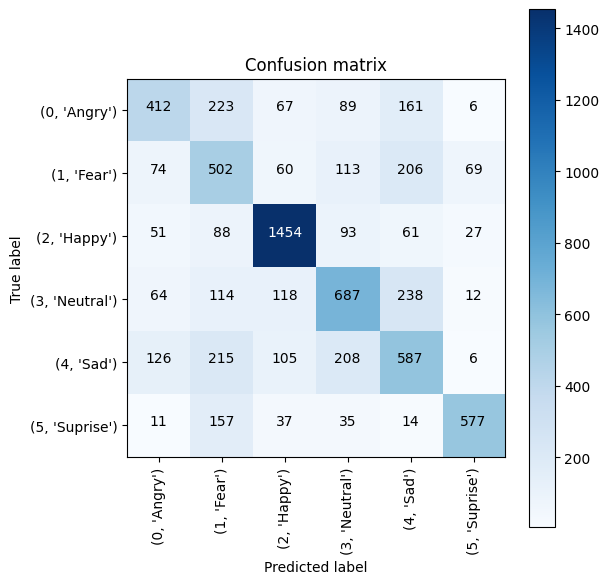

In [41]:
# Validate on test set

predictions = model.predict(X_test)
y_pred = [np.argmax(probas) for probas in predictions]


accuracy = accuracy_score(y_test, y_pred)
print('Test Accuracy = %.2f' % accuracy)

confusion_mtx = confusion_matrix(y_test, y_pred)
cm = plot_confusion_matrix(confusion_mtx, classes = list(test_labels.items()), normalize=False)

**Let's try our model and make predictions**

In [43]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen_test = ImageDataGenerator(rescale=1./255)

pred_generator = datagen_test.flow_from_directory(
    TEST_DIR,
    target_size=(48, 48),
    color_mode="grayscale",
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)


Found 7067 images belonging to 6 classes.


In [44]:
new_predictions = model.predict(X_test)
y_pred = [np.argmax(probas) for probas in new_predictions]
y_pred = [test_labels[k] for k in y_pred]

221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step


In [45]:
filenames = pred_generator.filenames
actual_class = [test_labels[h] for h in pred_generator.classes]

In [46]:
import pandas as pd

pred_result = pd.DataFrame({"Filename":filenames,
                           "Predictions":y_pred,
                           "Actual Values":actual_class})

pred_result.head()

,Filename,Predictions,Actual Values
0,Angry/Angry-1.jpg,Fear,Angry
1,Angry/Angry-10.jpg,Angry,Angry
2,Angry/Angry-100.jpg,Angry,Angry
3,Angry/Angry-101.jpg,Angry,Angry
4,Angry/Angry-102.jpg,Fear,Angry


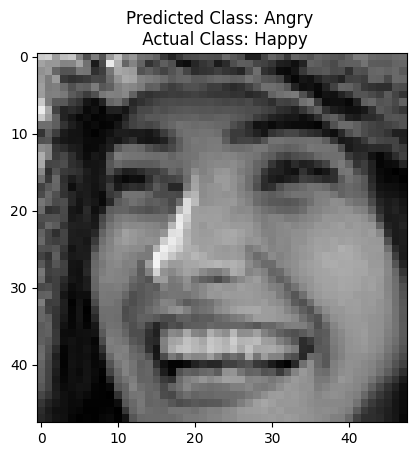

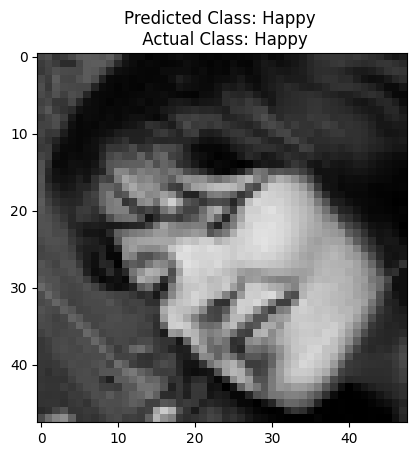

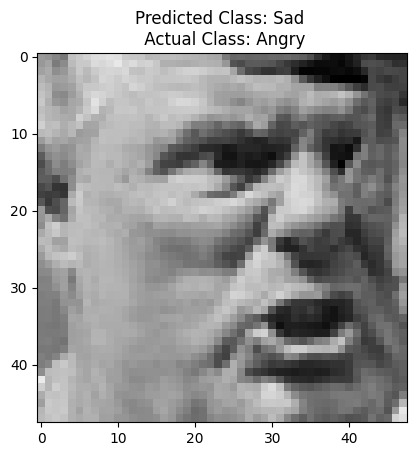

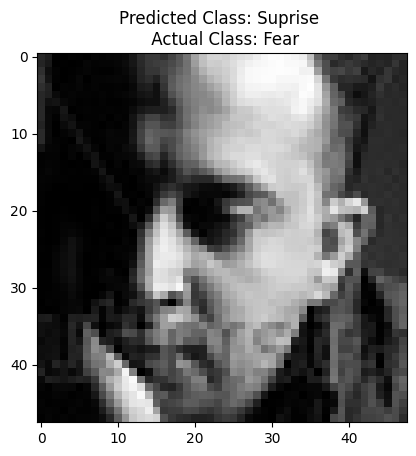

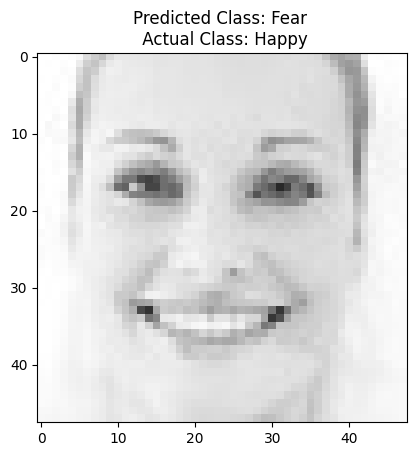

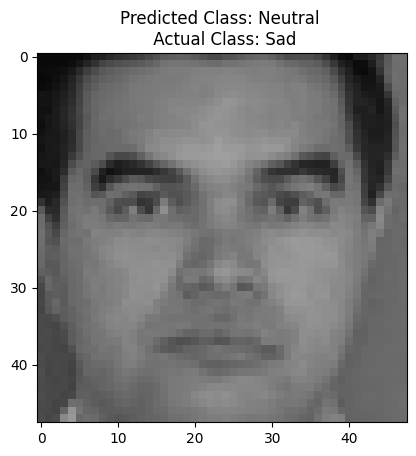

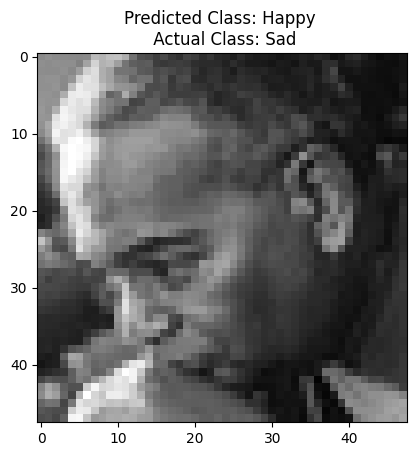

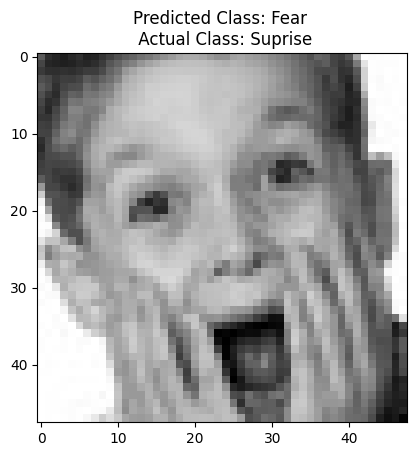

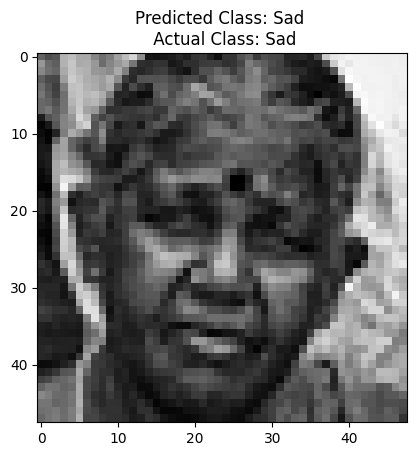

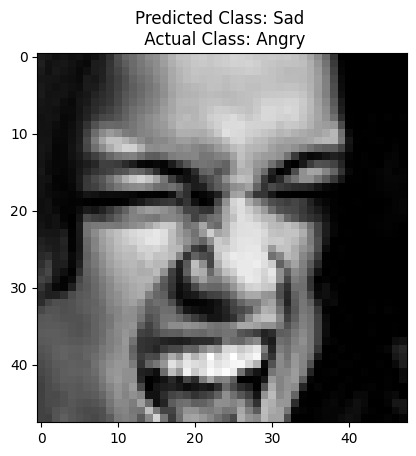

In [47]:
from random import randint

l = len(filenames)
base_path = TEST_DIR
for i in range(10):  # 10 images

    rnd_number = randint(0,l-1)
    filename,pred_class,actual_class = pred_result.loc[rnd_number]

    img_path = os.path.join(base_path,filename)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.title("Predicted Class: {} {} Actual Class: {}".format(pred_class,'\n',actual_class))
    plt.show()
    pass

In [50]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten,
    Dense, Dropout, BatchNormalization
)

def build_cnn_model(input_shape=(48, 48, 1), num_classes=6):

    model = Sequential()

    # Block 1
    model.add(Conv2D(32, (3,3), activation="relu", padding="same", input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2,2)))
    model.add(Dropout(0.25))

    # Block 2
    model.add(Conv2D(64, (3,3), activation="relu", padding="same"))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2,2)))
    model.add(Dropout(0.25))

    # Block 3
    model.add(Conv2D(128, (3,3), activation="relu", padding="same"))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2,2)))
    model.add(Dropout(0.4))

    # Classifier
    model.add(Flatten())
    model.add(Dense(256, activation="relu"))
    model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation="softmax"))

    return model

In [51]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

def deep_model(model, X_train, Y_train, epochs, batch_size):

    model.compile(
        loss="categorical_crossentropy",   # ✅ correct for 6 classes
        optimizer=Adam(learning_rate=1e-3),
        metrics=["accuracy"]
    )

    callbacks = [
        EarlyStopping(
            monitor="loss",
            patience=3,
            restore_best_weights=True
        )
    ]

    history = model.fit(
        X_train,
        Y_train,
        epochs=epochs,
        batch_size=batch_size,
        verbose=1
    )

    return history


In [52]:
epochs = 20
batch_size = 64

history = deep_model(model, X_train, Y_train, epochs, batch_size)


Epoch 1/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 52s 99ms/step - accuracy: 0.2556 - loss: 1.8429
Epoch 2/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 39s 88ms/step - accuracy: 0.2527 - loss: 1.7606
Epoch 3/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 39s 89ms/step - accuracy: 0.2559 - loss: 1.7577
Epoch 4/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 39s 88ms/step - accuracy: 0.2517 - loss: 1.7607
Epoch 5/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 39s 88ms/step - accuracy: 0.2560 - loss: 1.7580
Epoch 6/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 38s 87ms/step - accuracy: 0.2532 - loss: 1.7600
Epoch 7/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 38s 86ms/step - accuracy: 0.2504 - loss: 1.7606
Epoch 8/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 38s 86ms/step - accuracy: 0.2521 - loss: 1.7611
Epoch 9/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 38s 86ms/step - accuracy: 0.2594 - loss: 1.7557
Epoch 10/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 38s 86ms/step - accuracy: 0.2531 - loss: 1.7593
Epoch 11/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 38s 86ms/step - accuracy: 0.2526 - loss: 1.7591
Epoch 12/20
442/442 ━━━━━━━━━━

In [54]:
# Install kagglehub
!pip -q install kagglehub

import kagglehub
import os

# Download FER2013 dataset via kagglehub
dataset_path = kagglehub.dataset_download("msambare/fer2013")

# Set correct paths for Colab
train_dir = os.path.join(dataset_path, "train")
test_dir  = os.path.join(dataset_path, "test")

print("Dataset downloaded to:", dataset_path)
print("Train dir:", train_dir)
print("Test dir :", test_dir)



Using Colab cache for faster access to the 'fer2013' dataset.
Dataset downloaded to: /kaggle/input/fer2013
Train dir: /kaggle/input/fer2013/train
Test dir : /kaggle/input/fer2013/test


In [55]:
train_datagen = ImageDataGenerator(
    width_shift_range = 0.1,        # Randomly shift the width of images by up to 10%
    height_shift_range = 0.1,       # Randomly shift the height of images by up to 10%
    horizontal_flip = True,         # Flip images horizontally at random
    rescale = 1./255,               # Rescale pixel values to be between 0 and 1
    validation_split = 0.2          # Set aside 20% of the data for validation
)

validation_datagen = ImageDataGenerator(
    rescale = 1./255,               # Rescale pixel values to be between 0 and 1
    validation_split = 0.2          # Set aside 20% of the data for validation
)

In [56]:
train_generator = train_datagen.flow_from_directory(
    directory = train_dir,           # Directory containing the training data
    target_size = (48, 48),          # Resizes all images to 48x48 pixels
    batch_size = 64,                 # Number of images per batch
    color_mode = "grayscale",        # Converts the images to grayscale
    class_mode = "categorical",      # Classifies the images into 7 categories
    subset = "training"              # Uses the training subset of the data
)

validation_generator = validation_datagen.flow_from_directory(
    directory = test_dir,            # Directory containing the validation data
    target_size = (48, 48),          # Resizes all images to 48x48 pixels
    batch_size = 64,                 # Number of images per batch
    color_mode = "grayscale",        # Converts the images to grayscale
    class_mode = "categorical",      # Classifies the images into 7 categories
    subset = "validation"            # Uses the validation subset of the data
)

Found 22968 images belonging to 7 classes.
Found 1432 images belonging to 7 classes.


In [58]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Dense, Dropout, Flatten,
    Conv2D, MaxPooling2D, BatchNormalization
)
from tensorflow.keras.models import Sequential

# Define the model
model = Sequential([
    Input(shape=(48, 48, 1)),   # ✅ proper input layer

    Conv2D(32, (3,3), activation='relu'),
    BatchNormalization(),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    Dense(7, activation='softmax')
])

# ✅ Correct optimizer usage
model.compile(
    loss="categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    metrics=["accuracy"]
)

model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 46, 46, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 44, 44, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 44, 44, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 20, 20, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 18, 18, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 18, 18, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 7, 7, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 7, 7, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 5, 5, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 5, 5, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,394,183 (5.32 MB)

 Trainable params: 1,391,943 (5.31 MB)

 Non-trainable params: 2,240 (8.75 KB)

In [60]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint_callback = ModelCheckpoint(
    filepath="model.weights.h5",   # ✅ FIXED filename
    monitor="val_accuracy",
    save_best_only=True,
    save_weights_only=True,
    mode="max",
    verbose=1
)

history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=50,
    validation_data=validation_generator,
    validation_steps=len(validation_generator),
    callbacks=[checkpoint_callback]
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning:

Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.



Epoch 1/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - accuracy: 0.1659 - loss: 2.9220
Epoch 1: val_accuracy improved from -inf to 0.19064, saving model to model.weights.h5
359/359 ━━━━━━━━━━━━━━━━━━━━ 142s 354ms/step - accuracy: 0.1660 - loss: 2.9215 - val_accuracy: 0.1906 - val_loss: 1.9092
Epoch 2/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.2138 - loss: 2.4663
Epoch 2: val_accuracy improved from 0.19064 to 0.31913, saving model to model.weights.h5
359/359 ━━━━━━━━━━━━━━━━━━━━ 34s 94ms/step - accuracy: 0.2138 - loss: 2.4661 - val_accuracy: 0.3191 - val_loss: 1.7744
Epoch 3/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.2574 - loss: 2.2092
Epoch 3: val_accuracy improved from 0.31913 to 0.36243, saving model to model.weights.h5
359/359 ━━━━━━━━━━━━━━━━━━━━ 35s 96ms/step - accuracy: 0.2574 - loss: 2.2091 - val_accuracy: 0.3624 - val_loss: 1.6624
Epoch 4/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.2917 - loss: 2.0765
Epoch 4: val_accuracy improv

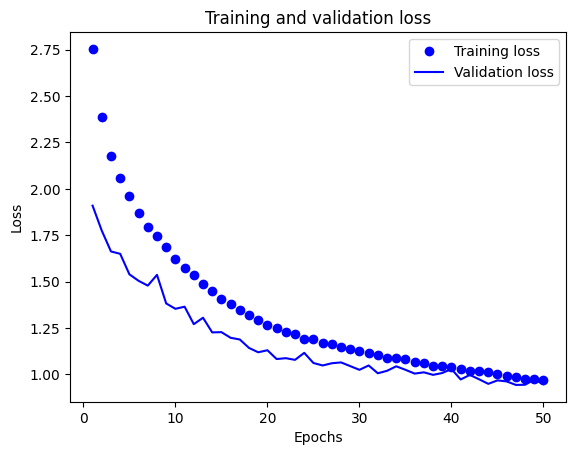

In [61]:
# Plot the train and validation loss
train_loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(train_loss) + 1)
plt.plot(epochs, train_loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

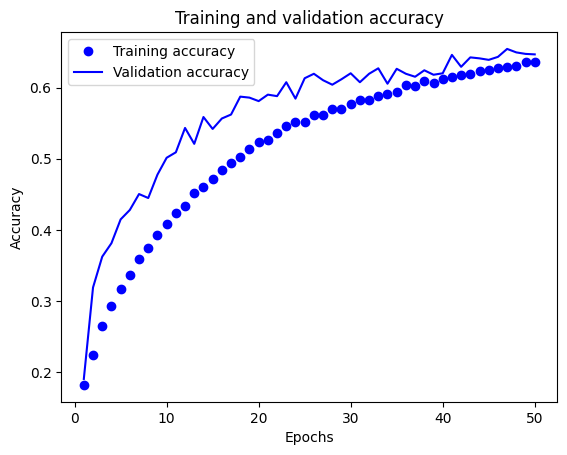

In [62]:
# Plot the train and validation accuracy
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
plt.plot(epochs, train_acc, 'bo', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 195ms/step


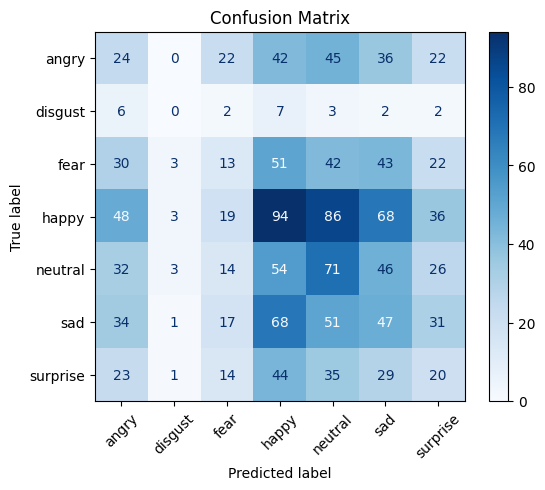

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Reset generator (IMPORTANT)
validation_generator.reset()

# Get predictions
y_pred_prob = model.predict(validation_generator)
y_pred = np.argmax(y_pred_prob, axis=1)

# True labels
y_true = validation_generator.classes

# Class names
class_names = list(validation_generator.class_indices.keys())

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()


In [26]:
# ===============================
# 1. Imports
# ===============================
import os
import cv2
import numpy as np
import kagglehub

from sklearn.model_selection import train_test_split


# ===============================
# 2. Download Dataset (kagglehub)
# ===============================
dataset_path = kagglehub.dataset_download(
    "tapakah68/facial-emotion-recognition"
)

print("Dataset downloaded at:", dataset_path)


Using Colab cache for faster access to the 'facial-emotion-recognition' dataset.
Dataset downloaded at: /kaggle/input/facial-emotion-recognition


In [27]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
from tensorflow.keras import layers, models

In [28]:

# ===============================
# 3. Constants
# ===============================
IMG_SIZE = 48
NUM_CLASSES = 8

EMOTIONS = [
    "Anger",
    "Contempt",
    "Disgust",
    "Fear",
    "Happy",
    "Neutral",
    "Sad",
    "Surprised"
]

DATA_DIR = os.path.join(dataset_path, "images")


# ===============================
# 4. Verify Dataset Structure
# ===============================
print("Available folders:", os.listdir(DATA_DIR))

Available folders: ['7', '17', '2', '10', '5', '8', '12', '0', '18', '16', '13', '15', '3', '1', '14', '4', '9', '6', '11']


In [29]:
def load_data(data_dir):
    images = []
    labels = []

    for label in range(NUM_CLASSES):
        class_dir = os.path.join(data_dir, str(label))

        if not os.path.isdir(class_dir):
            print(f"Missing folder: {class_dir}")
            continue

        for img_name in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_name)

            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue

            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            images.append(img)
            labels.append(label)

    return np.array(images), np.array(labels)


# ===============================
# 6. Load Dataset
# ===============================
images, labels = load_data(DATA_DIR)

print("Total images loaded:", images.shape[0])


# ===============================
# 7. Train-Test Split
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    images,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)


# ===============================
# 8. Normalize Pixel Values
# ===============================
X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0


# ===============================
# 9. Reshape for CNN Input
# ===============================
X_train = X_train.reshape(-1, IMG_SIZE, IMG_SIZE, 1)
X_test  = X_test.reshape(-1, IMG_SIZE, IMG_SIZE, 1)


# ===============================
# 10. Final Sanity Check
# ===============================
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)



Total images loaded: 64
X_train shape: (51, 48, 48, 1)
X_test shape : (13, 48, 48, 1)
y_train shape: (51,)
y_test shape : (13,)


Number of images: 64
Shape of images array: (64, 48, 48)
Number of labels: 64


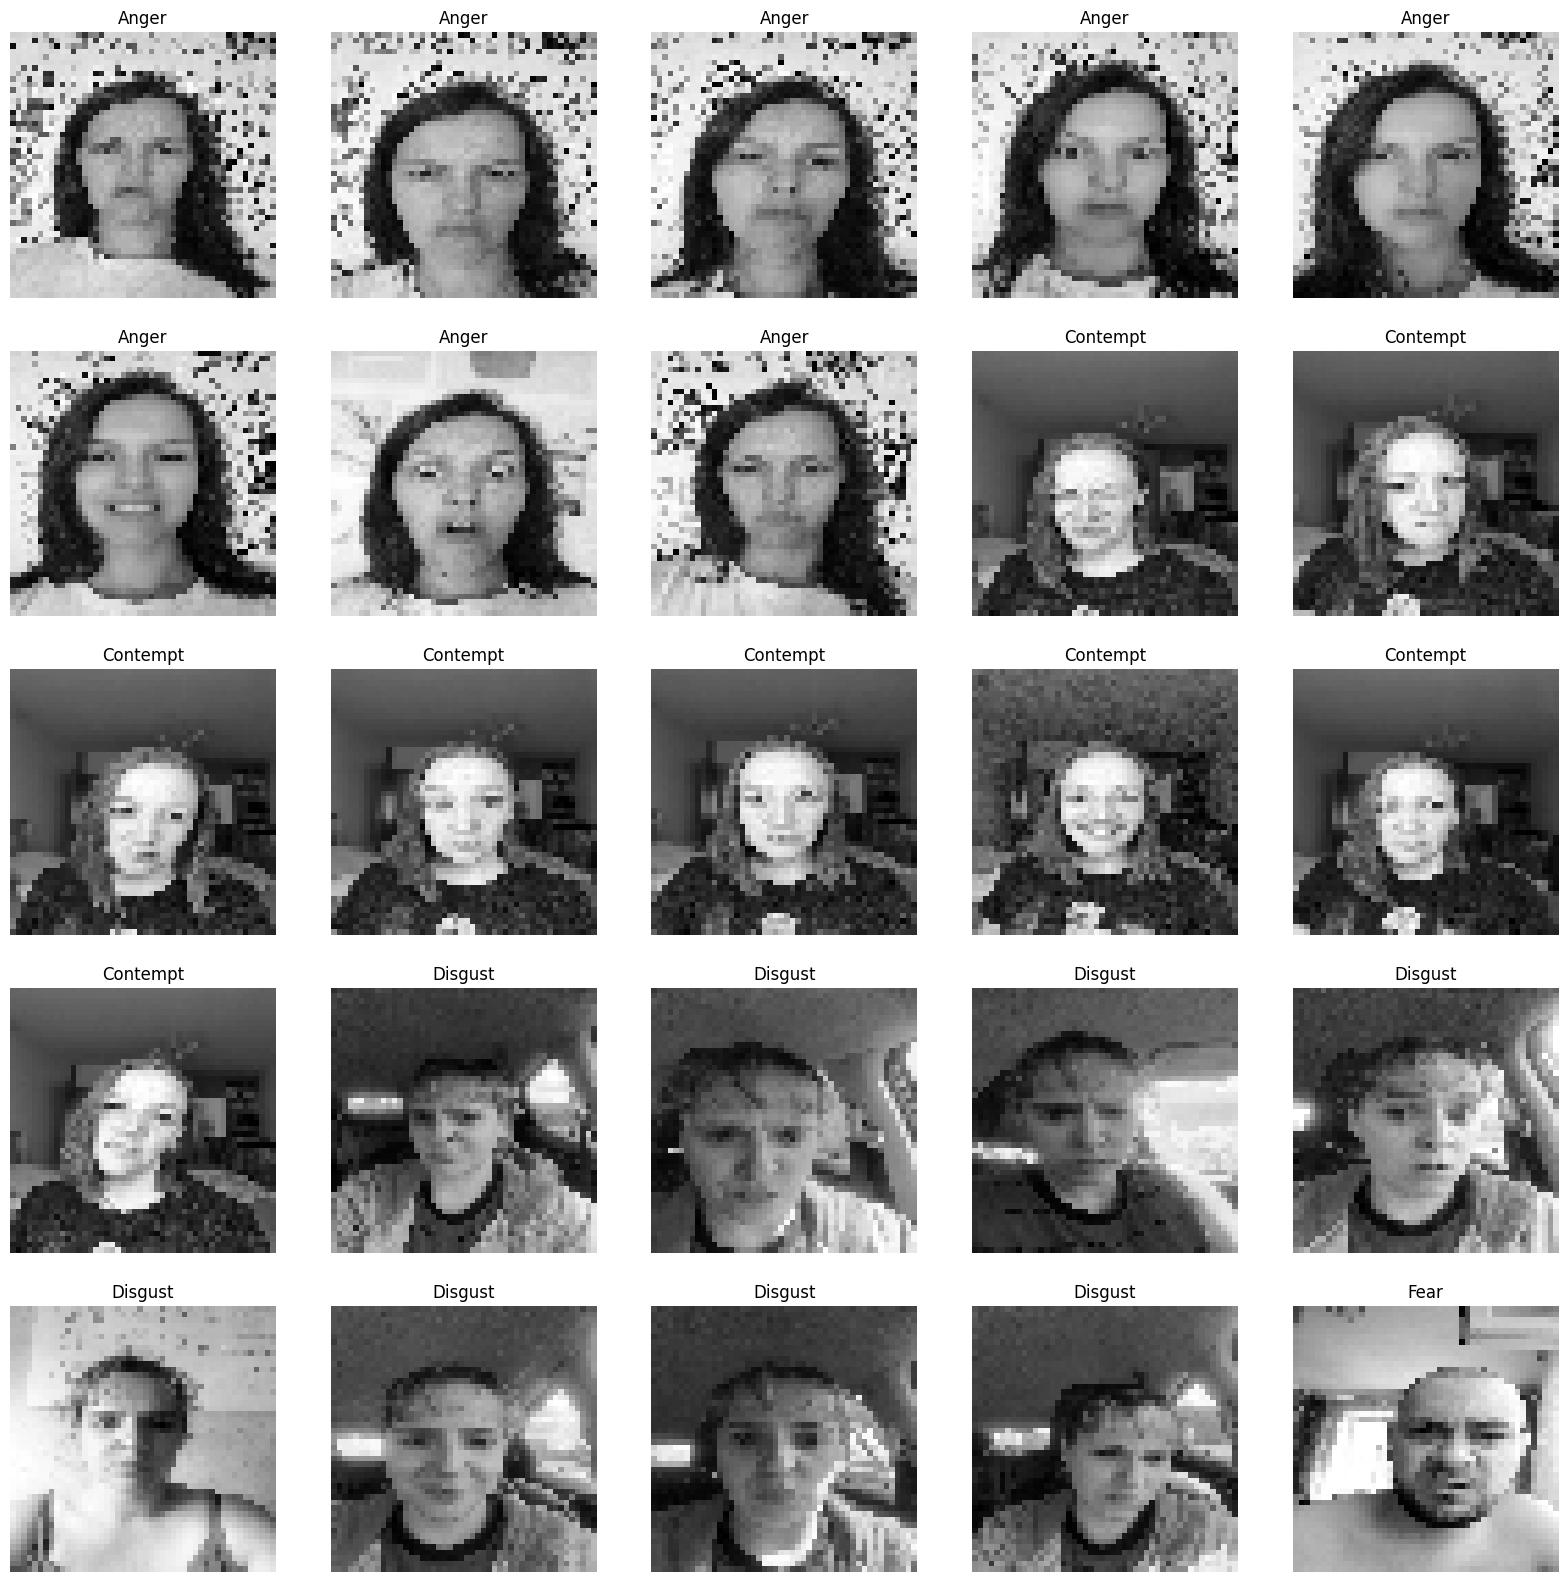

In [30]:
# Print information about the dataset
print("Number of images:", len(images))
print("Shape of images array:", images.shape)
print("Number of labels:", len(labels))

# Print sample images and their corresponding labels
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 20))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(EMOTIONS[labels[i]])
    plt.axis('off')
plt.show()

In [31]:
# Data augmentation
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(X_train)

In [32]:
# Define the CNN model
model = models.Sequential([
    layers.Conv2D(64, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),  # Dropout layer to prevent overfitting
    layers.Dense(len(EMOTIONS), activation='softmax')
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 485,384 (1.85 MB)

 Trainable params: 485,384 (1.85 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
import tensorflow as tf
from tensorflow.keras import backend as K
import gc

K.clear_session()   # clears the current TF graph
gc.collect()        # frees memory


0

In [34]:
import tensorflow as tf

class StopAtAccuracy(tf.keras.callbacks.Callback):
    def __init__(self, target=0.75):
        super().__init__()
        self.target = target

    def on_epoch_end(self, epoch, logs=None):
        acc = logs.get("accuracy")
        if acc is not None and acc >= self.target:
            print(f"\nReached {acc:.2f} accuracy. Stopping training.")
            self.model.stop_training = True

stop_callback = StopAtAccuracy(target=0.75)

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=19,
    validation_data=(X_test, y_test),
    callbacks=[stop_callback]
)


Epoch 1/19


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 3s/step - accuracy: 0.0654 - loss: 2.0885 - val_accuracy: 0.0769 - val_loss: 2.0705
Epoch 2/19
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.1332 - loss: 2.0748 - val_accuracy: 0.2308 - val_loss: 2.0517
Epoch 3/19
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.1703 - loss: 2.0762 - val_accuracy: 0.0769 - val_loss: 2.0490
Epoch 4/19
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.2167 - loss: 2.0377 - val_accuracy: 0.0769 - val_loss: 2.0425
Epoch 5/19
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.1332 - loss: 2.0828 - val_accuracy: 0.0769 - val_loss: 2.0340
Epoch 6/19
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.2360 - loss: 2.0044 - val_accuracy: 0.1538 - val_loss: 2.0141
Epoch 7/19
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.2533 - loss: 1.9812 - val_accuracy: 0.1538 - val_loss: 1.9901
Epoch 8/19
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.3133 - loss: 1.9732 - val_accuracy: 0.2308 - val_loss: 1.9490
Epoch 9/19
2/

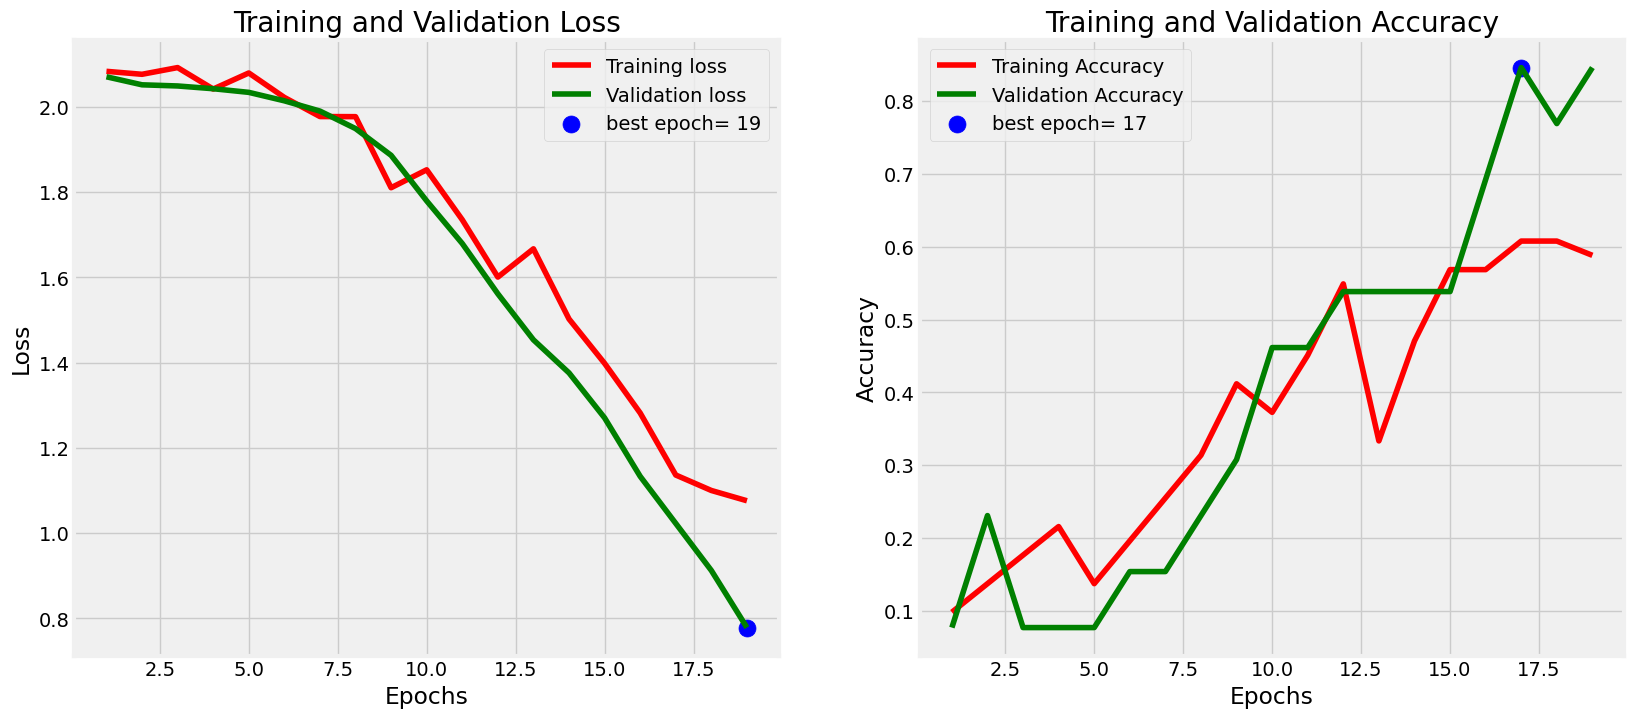

In [35]:
# Define needed variables
tr_acc = history.history['accuracy']
tr_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']
index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]

Epochs = [i+1 for i in range(len(tr_acc))]
loss_label = f'best epoch= {str(index_loss + 1)}'
acc_label = f'best epoch= {str(index_acc + 1)}'

# Plot training history
plt.figure(figsize= (20, 8))
plt.style.use('fivethirtyeight')

plt.subplot(1, 2, 1)
plt.plot(Epochs, tr_loss, 'r', label= 'Training loss')
plt.plot(Epochs, val_loss, 'g', label= 'Validation loss')
plt.scatter(index_loss + 1, val_lowest, s= 150, c= 'blue', label= loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(Epochs, tr_acc, 'r', label= 'Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label= 'Validation Accuracy')
plt.scatter(index_acc + 1 , acc_highest, s= 150, c= 'blue', label= acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout
plt.show()

In [36]:
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=2)

print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

1/1 - 0s - 42ms/step - accuracy: 0.8462 - loss: 0.7786
Test Loss: 0.7785915732383728
Test Accuracy: 0.8461538553237915


In [37]:
from sklearn.metrics import classification_report

# Make predictions on the test set
predictions = model.predict(X_test)
predicted_labels = np.argmax(predictions, axis=1)

# Print classification report
print(classification_report(y_test, predicted_labels, target_names=EMOTIONS))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
              precision    recall  f1-score   support

       Anger       1.00      1.00      1.00         1
    Contempt       0.33      1.00      0.50         1
     Disgust       0.00      0.00      0.00         2
        Fear       1.00      1.00      1.00         2
       Happy       1.00      1.00      1.00         2
     Neutral       1.00      1.00      1.00         1
         Sad       1.00      1.00      1.00         2
   Surprised       1.00      1.00      1.00         2

    accuracy                           0.85        13
   macro avg       0.79      0.88      0.81        13
weighted avg       0.79      0.85      0.81        13



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
